# **Convolutional Neural Network for Image Classification**

**Image Processing and Computer Vision



---
# Environment Setup & Library Imports
This section installs and imports the necessary Python libraries for training and evaluating deep learning models using PyTorch. It includes:



*   Torch & torchvision for model building and image processing,
*   torchmetrics for evaluation metrics,
*   tqdm for progress bars,
*   PIL for image handling,
*   matplotlib and pandas for visualization and data analysis,
*   torchsummary for model summaries,
*   Utilities like random, os, and copy for reproducibility and file handling.
---


In [ ]:
!pip install torchmetrics
from pathlib import Path
from PIL import Image
import PIL
import torch
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple, Callable, Optional
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm import tqdm
import torchmetrics
from torchsummary import summary
import numpy as np
import random
import torchvision
import  matplotlib.pyplot as plt
import os
import copy
import pandas as pd

---
# Oxford Pet Dataset Loader

This section clones the assignment repository and defines a custom PyTorch Dataset class OxfordPetDataset to load the Oxford Pet image classification dataset.
Key features:


*   Loads image_label pairs for a given split (`train`, `val`, or `test`)

* Applies optional image transformations

* Parses annotations from text files

* Provides the total number of classes via `get_num_classes()`
---

In [ ]:
!git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        self.root = Path("ipcv-assignment-2") / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

fatal: destination path 'ipcv-assignment-2' already exists and is not an empty directory.


---
## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

---
# Data Preparation

This section ensures consistent and reproducible results, sets the computation device, and prepares image preprocessing:

Seed Fixing:
* `fix_random()` sets seeds for NumPy, Python, and PyTorch (CPU & GPU) to ensure reproducibility.

Transforms:
* Defines data preprocessing pipelines for:

    * Basic center cropping (`get_center_crop_pipeline`)

    * Augmentation + normalization (`get_augmentation_norm_pipeline`)

    * Center cropping + normalization (`get_center_norm_pipeline`)

Mean & Std Calculation:
* Uses the training dataset to compute per-channel mean and standard deviation, which are essential for image normalization during training.
---

In [ ]:
seed = 42
no_of_classes = 37
resize_size = 300
crop_size = 256

def fix_random(seed: int) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


g = torch.Generator()
g.manual_seed(seed)
fix_random(seed)

def compute_mean_and_std(loader):
    """
    Calculate per-channel mean and standard deviation over the entire dataset.

    Args:
        loader (DataLoader): DataLoader yielding (images, labels).

    Returns:
        tuple: (means, stds) as lists of floats.
    """
    # Accumulators for channel sums and squared differences
    sum_channels = np.zeros(3, dtype=np.float64)
    sum_squared_diff = np.zeros(3, dtype=np.float64)
    pixel_count = 0

    # First pass: accumulate sums to compute mean
    for images, _ in loader:
        batch_size, channels, height, width = images.shape
        num_pixels = batch_size * height * width
        pixel_count += num_pixels

        # Sum per channel
        for i in range(channels):
            sum_channels[i] += images[:, i, :, :].sum().item()

    # Compute mean for each channel
    channel_means = sum_channels / pixel_count

    # Second pass: accumulate squared differences from mean
    for images, _ in loader:
        for i in range(3):
            diffs = images[:, i, :, :] - channel_means[i]
            sum_squared_diff[i] += (diffs ** 2).sum().item()

    # Standard deviation per channel
    channel_stds = np.sqrt(sum_squared_diff / pixel_count)

    return channel_means.tolist(), channel_stds.tolist()

---
# Image Transformations

This section defines and uses three key transformations to preprocess images from the Oxford Pet dataset before feeding them into deep learning models:

1. Center Transform

    * Used to compute the per-channel mean and standard deviation of the training set.
It resizes each image to a fixed size (`resize_size`) and then center-crops it to a target size (`crop_size`) to ensure consistent spatial dimensions. Finally, it converts the image into a tensor.

2. Data Augmentation and Normalization Transform

  Designed for training with data augmentation. It:

    * Randomly resizes and crops the image (`RandomResizedCrop`)

    * Randomly applies horizontal flips (50% probability)

    * Converts the image to a tensor

    * Normalizes it using the previously computed mean and standard deviation values

3. Center and Normalization Transform

  * Similar to the Center Transform, but with added normalization. This is typically used for validation or testing, where no augmentation is desired, but normalization ensures consistent input distribution.

These transformations are crucial for:

  * Standardizing input sizes across all images

  * Enhancing generalization via augmentation

  * Normalizing pixel values for better model convergence

A helper function `get_dataloader()` is also defined to easily create dataloaders for different dataset splits (`train`, `val`, `test`) using these transforms.

---

In [ ]:

def get_center_crop_pipeline(resize_size, crop_size):
    return transforms.Compose([transforms.Resize(resize_size),
                               transforms.CenterCrop(crop_size),
                               transforms.ToTensor()])
def get_augmentation_norm_pipeline(crop_size, mean, std):
    return transforms.Compose([transforms.RandomResizedCrop(crop_size),
                               transforms.RandomHorizontalFlip(),
                               transforms.ToTensor(),
                               transforms.Normalize(mean=mean, std=std)])
def get_center_norm_pipeline(resize_size, crop_size, mean, std):
    return transforms.Compose([transforms.Resize(resize_size),
                               transforms.CenterCrop(crop_size),
                               transforms.ToTensor(),
                               transforms.Normalize(mean=mean, std=std)])

def get_dataloader(split, transform, batch_size, shuffle, num_workers):
    dataset = OxfordPetDataset(split, transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)

In [ ]:
base_trainloader =  get_dataloader(
    split ='train',
    transform = get_center_crop_pipeline(resize_size, crop_size),
    batch_size = 128,
    shuffle = False,
    num_workers = 2)

mean, std  = compute_mean_and_std(base_trainloader)
print(f"Channel means: {mean}")
print(f"Channel stds: {std}")

Channel means: [0.49081850194840054, 0.45195749469464924, 0.39703177054138267]
Channel stds: [0.2629709132757854, 0.2580487928624617, 0.26475132424016634]


---
# Model Structure & Customization



The **`Oxford Pet dataset`** class is composed of:
1. **Stem Layer**:

  * A configurable initial layer responsible for reducing the spatial resolution of input images. This helps in controlling the computational cost (`FLOPs`) and memory usage of the network before deeper layers are applied.

2. **Stage Layers**:

  A sequence of convolutional blocks (called stages) defined via constructor arguments. Each stage:
    * Doubles the number of channels, increasing feature representation capacity

    * Halves the spatial dimensions, progressively reducing image size
This staged structure enables deeper hierarchical feature extraction while managing complexity.

3. **Classification Head**:

A fixed module at the end of the network, composed of:
  * Global Average Pooling, which compresses spatial dimensions
  * A fully connected (linear) layer that outputs class predictions (for 37 pet breeds in this case)

Additionally, the constructor allows customization through two parameters:

* `activation_layer` (Activation Layer):

  Specifies the type of activation function used (e.g., `ReLU`, `LeakyReLU`). It accepts any callable that returns a PyTorch activation module.

  *`normaliation_layer` (Normalization Layer):

  Defines the normalization method applied in the network (e.g., `BatchNorm2d`, `Identity`). This provides flexibility in designing experiments and controlling model regularization.

This modular design allows the model to be adapted easily for different architectural variants and training strategies while staying efficient for pet classification tasks.

---

---
# Convolution Block Module Overview
The ConvolutionBlock is a flexible building block used in convolutional neural networks, designed to process input feature maps through a sequence of layers. Its components include:

1. **2D Convolution Layer**
  * Performs a 2D convolution operation with customizable parameters such as the number of input/output channels, kernel size, stride, and padding. This layer extracts spatial features from the input.

2. **Normalization Layer** `(normaliation_layer`)
  * Applies a normalization operation to stabilize and accelerate training. This could be a standard normalization method like BatchNorm2d or a placeholder like Identity, based on what's passed to the constructor.

3. **Activation Layer** (`activation_layer`)
  * Introduces non-linearity to the block using an activation function (e.g., `ReLU`, `LeakyReLU`, etc.). The activation layer is also passed as a callable during initialization, allowing for easy customization.

4. **Dropout Layer**
  * Optionally applies dropout to randomly deactivate a fraction of the neurons during training, helping to reduce overfitting. The dropout behavior is controlled via a `drop_rate` parameter.

This modular design allows the `ConvolutionBlock` to be easily reused and adapted within various model architectures.

---

---
# Inception Block Module
The `InceptionBlock` is a custom PyTorch module inspired by the GoogLeNet architecture. It processes the same input tensor through four parallel branches, each using different convolution or pooling operations to capture diverse spatial features. The total number of output channels is divided equally across the four branches, each contributing 1/4 of the specified `out_channels`.
Here's a breakdown of each branch:

1. **Branch 1**
  * Applies a 1×1 convolution, outputting 1/4 of the total `out_channels`.

2. **Branch 2**
  * Starts with a 1×1 convolution producing 1/8 of `out_channels`, followed by a 3×3 convolution to bring the output to 1/4 of `out_channels`.

3. **Branch 3**
  * Similar to Branch 2, but uses a 5×5 convolution after the initial 1×1 convolution. The final output is again 1/4 of `out_channels`.

4. Branch 4
  * Performs a max pooling operation (preserving spatial dimensions), followed by a 1×1 convolution to generate 1/4 of the total output channels.

All convolutional layers in the block utilize the previously defined ConvolutionBlock class for consistent normalization, activation, and optional dropout.
* The output spatial dimensions remain unchanged from the input, ensuring that the block can be stacked without altering feature map sizes.

This design allows the model to learn multi-scale features efficiently while maintaining computational control.

---



---

The `InceptionStage` module is a sequential container that processes input through two Inception blocks followed by a downsampling step using max pooling.

1. **Initial Inception Block**: Expands the feature representation by increasing the number of channels from `in_channels` to `out_channels` (specifically, `out_channels` is set to twice `in_channels`), enriching the model's capacity to extract complex patterns.

2. **Secondary Inception Block**: Applies another `InceptionBlock` that keeps the number of channels constant at `out_channels`, further refining the feature maps without altering the depth.

3. **Downsampling via Max Pooling**: A `MaxPool2d` layer is then used to reduce the spatial resolution of the feature maps by a factor of 2, helping to progressively shrink the spatial dimensions as the model deepens.

Overall, this stage increases the depth of the features while reducing their width and height, enabling deeper hierarchical learning and computational efficiency.

---


In [ ]:
class ConvolutionBlock(torch.nn.Module):
    def __init__(self, in_channels: int,
                 out_channels: int,
                 kernel_size: int,
                 stride: int,
                 padding: int,
                 activation_layer,
                 normaliation_layer,
                 dropout_rate: float):
        super(ConvolutionBlock,self).__init__()
        self.conv2d = torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.normaliation_layer = normaliation_layer(out_channels)
        self.activation_layer = activation_layer()
        self.dropout_rate = dropout_rate

    def forward(self,x):
        x = self.conv2d(x)
        x = self.normaliation_layer(x)
        x = self.activation_layer(x)
        if self.dropout_rate>0:
          x = torch.nn.Dropout(self.dropout_rate)(x)
        return x

class InceptionBlock(torch.nn.Module):
    def __init__(self, in_channels: int,
                 out_channels: int,
                 activation_layer,
                 normaliation_layer,
                 dropout_rate: float):
        super(InceptionBlock,self).__init__()
        out_channel_1x1 = out_channels // 4
        red_3x3 = out_channel_1x1 // 2
        out_channel_3x3 = out_channel_1x1
        red_5x5 = out_channel_1x1 // 2
        out_channel_5x5 = out_channel_1x1
        out_channel_1x1_pooling = out_channel_1x1

        self.branch1 = ConvolutionBlock(in_channels = in_channels,out_channels = out_channel_1x1, kernel_size = 1, stride = 1, padding = 0, activation_layer = activation_layer, normaliation_layer = normaliation_layer, dropout_rate = dropout_rate)

        self.branch2 = torch.nn.Sequential(ConvolutionBlock(in_channels=in_channels, out_channels=red_3x3, kernel_size=1, stride=1,padding=0, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate),
                                           ConvolutionBlock(in_channels=red_3x3, out_channels=out_channel_3x3, kernel_size=3, stride=1, padding=1, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate))

        self.branch3 = torch.nn.Sequential(ConvolutionBlock(in_channels=in_channels, out_channels=red_5x5,kernel_size=1, stride=1, padding=0, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate),
                                           ConvolutionBlock(in_channels=red_5x5, out_channels=out_channel_5x5,kernel_size=5, stride=1, padding=2, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate))

        self.branch4 = torch.nn.Sequential(torch.nn.MaxPool2d(kernel_size=3,stride=1,padding=1),
                                           ConvolutionBlock(in_channels=in_channels, out_channels=out_channel_1x1_pooling, kernel_size=1, stride=1, padding=0, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate))

    def forward(self,x):
        return torch.cat([self.branch1(x),self.branch2(x),self.branch3(x),self.branch4(x)],dim=1)

class InceptionStage(torch.nn.Module):
    def __init__(self, in_channels, activation_layer, normaliation_layer, dropout_rate):
        super().__init__()
        out_channels = in_channels * 2
        self.blocks = torch.nn.Sequential(
            InceptionBlock(in_channels, out_channels, activation_layer, normaliation_layer, dropout_rate),
            InceptionBlock(out_channels, out_channels, activation_layer, normaliation_layer, dropout_rate),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
    def forward(self, x):
        return self.blocks(x)

# Deep 3*3 Layer with stride 2
class DeepStem(torch.nn.Module):
    def __init__(self, out_channels, activation_layer, normaliation_layer, dropout_rate):
        super().__init__()
        self.blocks = torch.nn.Sequential(
            ConvolutionBlock(3, out_channels, kernel_size=3, stride=2, padding=1, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate),
            ConvolutionBlock(out_channels, out_channels, kernel_size=3, stride=1, padding=1, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate),
            ConvolutionBlock(out_channels, out_channels, kernel_size=3, stride=1, padding=1, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate)
        )

    def forward(self, x):
        return self.blocks(x)

# A clasic Large Kernel layer of 7*7
class ClasicLargeKernelStem(torch.nn.Module):
    def __init__(self, out_channels, activation_layer, normaliation_layer, dropout_rate):
        super().__init__()
        self.block = ConvolutionBlock(3, out_channels, kernel_size=7, stride=2, padding=1, activation_layer=activation_layer, normaliation_layer=normaliation_layer, dropout_rate=dropout_rate)

    def forward(self, x):
        return self.block(x)


def create_model(cnf_model):
    model = PetIdentificationModel(
      activation_layer = cnf_model.activation,
      normaliation_layer = cnf_model.normalization,
      stem_layer = cnf_model.stem_layer,
      stage_layer = InceptionStage,
      dropout_head_layer = cnf_model.dropout_head_layer,
      dropout_feature_extraction = cnf_model.dropout_feature_extraction,
      stem_out_channels=64,
      num_stages=cnf_model.num_stages,
     no_of_classes=no_of_classes
    )
    model.to(device)
    return model

class SqueezeDims(torch.nn.Module):
    def forward(self, x):
        return x.squeeze()

class PetIdentificationModel(torch.nn.Module):
    def __init__(self,
                 activation_layer,
                 normaliation_layer,
                 stem_layer,
                 stage_layer,
                 dropout_head_layer: float,
                 dropout_feature_extraction: float,
                 stem_out_channels: int,
                 num_stages: int,
                no_of_classes: int):
        super(PetIdentificationModel, self).__init__()

        self.stem = torch.nn.Sequential(
            stem_layer(stem_out_channels, activation_layer, normaliation_layer, dropout_feature_extraction),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.stages = torch.nn.ModuleList()
        in_channels = stem_out_channels
        for _ in range(num_stages):
            stage = stage_layer(in_channels, activation_layer, normaliation_layer, dropout_feature_extraction)
            self.stages.append(stage)
            in_channels *= 2

        self.head = torch.nn.Sequential(
          torch.nn.AdaptiveAvgPool2d((1, 1)),
          SqueezeDims(),
          torch.nn.Dropout(dropout_head_layer),
          torch.nn.Linear(in_channels,no_of_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = self.head(x)
        return x

---
# Training of Model



The `train` function manages the full training workflow for a model. It:

  * Tracks training and validation accuracy across epochs.

  * Monitors the best validation accuracy achieved and implements early stopping if there’s no improvement for a defined number of consecutive epochs.

  * Logs both loss and accuracy for training and validation at each epoch, providing real-time feedback during the process.

  * Returns a `history` dictionary that stores performance metrics (losses and accuracies) for analysis or plotting after training.

---

---

The `process` function sets up and runs the full training pipeline. It prepares the dataloaders, calculates model complexity (FLOPs and parameters), configures the loss and optimizer, and executes the training loop. It returns the training history, best validation accuracy, and model complexity metrics.

---

In [ ]:
def train(model, num_epochs, criterion, opt, train_dl, val_dl,no_of_classes, earlystop_patience, scheduler, device):
    train_acc_fn = torchmetrics.Accuracy(task='multiclass',num_classes=no_of_classes).to(device)
    val_acc_fn = torchmetrics.Accuracy(task='multiclass',num_classes=no_of_classes).to(device)

    best_val_acc = 0.0
    epochs_without_improvement = 0

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_dl, criterion, opt, scheduler, train_acc_fn, device, epoch, num_epochs)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        val_loss, val_acc = validate_epoch(model, val_dl, criterion, val_acc_fn, device, epoch, num_epochs)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train_Loss: {train_loss:.4f} Train_Acc: {train_acc:.4f}")
        print(f"Val_Loss: {val_loss:.4f} Val_Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= earlystop_patience:
            print(f"Early stopping at {epoch+1} epochs due to no improvement.")
            break

    history = {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }
    return history, best_val_acc


def process(config, model, device, lr_groups_fn):

    train_dataloader = get_dataloader('train', config.train_transform, config.batch_size, True, config.workers)
    val_dataloader = get_dataloader('val', config.test_transform, config.batch_size, False, config.workers)
    test_dataloader = get_dataloader('test', config.test_transform, config.batch_size, False,config.workers)

    input_shape = (config.batch_size, 3, crop_size, crop_size)


    criterion = torch.nn.CrossEntropyLoss()
    # if config.label_smoothing >0:
    #   print("used smoothing")
    #   criterion = torch.nn.CrossEntropyLoss(config.label_smoothing)

    groups_dict, lrs = lr_groups_fn(model, config.lr)
    optimizer = optim.Adam(groups_dict, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lrs, steps_per_epoch=len(train_dataloader), epochs=config.n_epochs)
    history, best_val_acc = train(model,
                                  num_epochs = config.n_epochs,
                                  criterion = criterion,
                                  opt = optimizer,
                                  train_dl = train_dataloader,
                                  val_dl = val_dataloader,
                                  no_of_classes = 43,
                                  earlystop_patience = config.patience,
                                  scheduler = scheduler,
                                  device=device)
    return history, best_val_acc

# Performs one training epoch
def train_epoch(model, train_dl, criterion, opt, scheduler, train_acc_fn, device, epoch, num_epochs):
    model.train()
    train_acc_fn.reset()
    running_loss = 0.0
    for inputs, targets in tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs}"):
        opt.zero_grad()
        outputs = model(inputs.to(device))
        loss = criterion(outputs, targets.to(device))
        loss.backward()
        opt.step()
        scheduler.step()
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_acc_fn.update(preds, targets.to(device))
    train_loss = running_loss / len(train_dl)
    train_acc = train_acc_fn.compute().item()
    return train_loss, train_acc

# Performs one validation epoch
def validate_epoch(model, val_dl, criterion, val_acc_fn, device, epoch, num_epochs):
    model.eval()
    val_acc_fn.reset()
    running_loss = 0.0
    with torch.no_grad():
        for inputs, targets in tqdm(val_dl, desc=f"Epoch {epoch+1}/{num_epochs}"):
            outputs = model(inputs.to(device))
            loss = criterion(outputs, targets.to(device))
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_acc_fn.update(preds, targets.to(device))
    val_loss = running_loss / len(val_dl)
    val_acc = val_acc_fn.compute().item()
    return val_loss, val_acc

---
# Configuration and Optimizer Utilities

* `update_config`:

  Takes a configuration dictionary `cnf`, a `key`, and a `new_value`. It returns a deep copy of the configuration with the specified key updated to the new value. If the key does not exist, it prints a warning message.It is designed to support the ablation study by enabling targeted updates to individual entries within a configuration dictionary (`cnf`), while maintaining the integrity of all other parameters.

* `get_param_lr_groups`:

  Prepares optimizer parameter groups for a model by including all model parameters with a uniform learning rate `lr`. Returns a list of parameter groups and a list containing the learning rate.

---

In [ ]:
class Config:
  def __init__(self):
        # Model settings
        self.activation = lambda: torch.nn.LeakyReLU()
        self.normalization = lambda channels: torch.nn.BatchNorm2d(channels)
        self.stem_layer = DeepStem
        self.dropout_head_layer = 0.3
        self.dropout_feature_extraction = 0.1
        self.num_stages = 4
        self.no_of_classes = 37
        self.label_smoothing =  0.0

        # Training settings
        self.batch_size = 64
        self.lr = 0.001
        self.weight_decay = 0.0005
        self.n_epochs = 30
        self.patience = 15
        self.use_single_block = False
        self.workers = 2

        # Transforms
        self.train_transform = None
        self.test_transform = None


  def set_train_transform(self, transform):
    self.train_transform = transform

  def set_test_transform(self, transform):
    self.test_transform = transform

def update_config(config_obj, attr_name, new_value):
    updated_config = copy.deepcopy(config_obj)
    if hasattr(updated_config, attr_name):
        setattr(updated_config, attr_name, new_value)
    else:
        print(f"Attribute '{attr_name}' not found in the configuration.")
    return updated_config

config = Config()
config.set_train_transform(get_augmentation_norm_pipeline(crop_size, mean, std))
config.set_test_transform(get_center_norm_pipeline(resize_size, crop_size, mean, std))


In [ ]:

def update_config(config_obj, attr_name, new_value):
    updated_config = copy.deepcopy(config_obj)
    if hasattr(updated_config, attr_name):
        setattr(updated_config, attr_name, new_value)
    else:
        print(f"Attribute '{attr_name}' not found in the configuration.")
    return updated_config

def get_param_lr_groups(model, lr):
  return [{'params': model.parameters(), 'lr': lr}], [lr]

# Ablation Study

Following model adjustments and hyperparameter tuning using  configurations, model was successfully trained, reaching an accuracy of approximately 60%. This setup will serve as the baseline for the upcoming ablation study.

Key characteristics of this baseline configuration include:

1. Model Architecture:

    * Activation function: LeakyReLU
    * Normalization: BatchNorm
    * Stem: DeepStem (three 3×3 convolutions)
    * Dropout: 0.3 in the classifier head, 0.1 throughout the feature extractor
    * Structure: 4 sequential InceptionStage modules

2. Training Setup:

    * Data augmentation applied to training images
    * Batch size: 64
    * Learning rate: 0.001
    * Weight decay: 0.0005
    * Total epochs: 30
    * Early stopping patience: 15 epochs

---

For the ablation study, a uniform learning rate across all network parameters is preferred, which is why the `get_param_lr_groups` function is used. Different learning rates will be introduced later in the second part of the assignment as needed.

---

---
### Summary of the Ablation Study

The ablation study is structured as follows, with each variant modifying a specific aspect of the baseline model to assess its impact on performance:

* **Baseline Configuration**: Uses the original model and training settings from `config`.

* **ReLU Activation**: Used ReLU instead of leakyReLU the number of InceptionStage blocks from 4 to 2.

* **Fewer Inception Stages**: Reduces the number of InceptionStage blocks from 4 to 2.

* **Reduced Dropout in Classifier Hea**d: Reduces dropout in the classifier head by setting dropout_head_layer from 0.3 to 0.1.

* **Removed Dropout in Feature Extractor**: Removes dropout from all feature extraction layers by setting dropout_feature_extraction to 0.0 .

* **Alternative Stem Design**: Replaces the DeepStem (three 3×3 convolutions) with a single 7×7 convolution in ClasicLargeKernelStem .

* **Without Batch Normalization**: Substitutes BatchNorm2d with identity layers to evaluate the effect of normalization .

* **Without Data Augmentation**: Removes all augmentation techniques from the training pipeline .

Results from all configurations are collected and stored in the results_df DataFrame for comparison and analysis.

---

In [ ]:
#Ablation Confuigurations
configs = {'base': config,
         'relu_activation': update_config(config, 'activation', lambda: torch.nn.ReLU()),
        '2stages': update_config(config, 'num_stages', 2),
        '7x7stem': update_config(config, 'stem_layer',ClasicLargeKernelStem),
         # 'use_label_smoothing': update_config(config, 'label_smoothing', 0.1),
        'no_data_augmentation': update_config(config, 'train_transform',  get_center_norm_pipeline(resize_size, crop_size, mean, std)),
        'reduces_droput_head': update_config(config, 'dropout_head_layer', 0.1),
        'no_dropout_feature_extraction': update_config(config, 'dropout_feature_extraction', 0.0),
        'without_normalization': update_config(config, 'normalization', lambda channels: torch.nn.Identity(channels)),
         }

In [ ]:
results = []
all_model_histories = []
for idx, (model_name, model_config) in enumerate(configs.items()):
    print(f'Evaluating {model_name} model')
    print()
    model = create_model(model_config)
    history, acc_value= process(model_config, model, device, get_param_lr_groups)
    all_model_histories.append(history)
    results.append([model_name, acc_value])

Evaluating base model



Epoch 1/30: 100%|██████████| 29/29 [00:13<00:00,  2.12it/s]


Epoch 1/30
Train_Loss: 3.6325 Train_Acc: 0.0463
Val_Loss: 3.4582 Val_Acc: 0.0856


Epoch 2/30: 100%|██████████| 29/29 [00:13<00:00,  2.14it/s]


Epoch 2/30
Train_Loss: 3.4243 Train_Acc: 0.0834
Val_Loss: 3.4409 Val_Acc: 0.0796


...

Epoch 14/30
Train_Loss: 3.6112 Train_Acc: 0.0275
Val_Loss: 3.6109 Val_Acc: 0.0273


Epoch 15/30: 100%|██████████| 29/29 [00:13<00:00,  2.15it/s]


Epoch 15/30
Train_Loss: 3.6111 Train_Acc: 0.0264
Val_Loss: 3.6108 Val_Acc: 0.0273


Epoch 16/30: 100%|██████████| 29/29 [00:13<00:00,  2.18it/s]

Epoch 16/30
Train_Loss: 3.6111 Train_Acc: 0.0256
Val_Loss: 3.6108 Val_Acc: 0.0273
Early stopping at 16 epochs due to no improvement.


# **Ablation Study Results**
This ablation study explores how changes to specific model architecture components and training settings affect performance. Each variant was tested independently, and the highest validation accuracy (`best_val_acc`) was recorded. Below is a summary of the results:

1. **Base Model**

  The base model includes LeakyReLU activations, a DeepStem (three 3×3 convolutions), 4 InceptionStage blocks, Batch Normalization, dropout in both the head (0.3) and feature extractor (0.1), and standard data augmentation. It achieves a validation accuracy of `65.10%`, serving as the benchmark for all other variants.

2. **ReLU Activation Instead of LeakyReLU**

  Switching from LeakyReLU to standard ReLU slightly reduces the performance to `64.89%`, indicating that the choice of activation function has minimal influence in this setup.

3. **Fewer Inception Stages (2 instead of 4)**

 Reducing the number of InceptionStage blocks from 4 to 2 leads to a noticeable performance drop, with accuracy falling to `46.40%`. This suggests that network depth plays a key role in capturing complex representations.

4. **7×7 Stem Layer (ClassicLargeKernelStem)**

  Replacing the DeepStem with a single 7×7 convolution in the stem lowers accuracy to `62.60%`, reinforcing the effectiveness of gradual feature extraction through smaller convolutions.

5. **No Data Augmentation**

  Disabling data augmentation during training results in a reduced validation accuracy of `60.96%`, highlighting its role in improving generalization and reducing overfitting.

6. **Reduced Dropout in Classifier Head**

  Lowering the dropout rate in the classifier head yields a modest performance boost, reaching `66.30%`. This suggests that lighter regularization in the head may benefit the model.

7. **No Dropout in Feature Extractor**

  Interestingly, removing dropout from the feature extractor layers leads to the best result across all variants, achieving `71.15%` accuracy. This implies that regularization in early layers may have been too aggressive.

8. **No Batch Normalizatio**n

  Eliminating Batch Normalization causes a drastic drop in accuracy to just `2.73%`, underscoring its essential role in maintaining training stability and enabling deep networks to learn effectively.

---

In [ ]:
columns = ['model_name', 'best_val_acc']
results_df = pd.DataFrame(results, columns = columns)
results_df

,model_name,best_val_acc
0,base,0.651036
1,relu_activation,0.648855
2,2stages,0.464013
3,7x7stem,0.625954
4,no_data_augmentation,0.609596
5,reduces_droput_head,0.663032
6,no_dropout_feature_extraction,0.711559
7,without_normalization,0.027263


---
The `ModelVisualizer ` class provides functionality to visualize training and validation metrics from multiple model histories. It also highlights the peak points in the validation accuracy curves for each model.

---

In [ ]:
class ModelVisualizer:
    def __init__(self, histories, model_names, best_acc):
        self.histories = histories
        self.model_names = model_names
        self.best_acc = best_acc

    def set_best_val_acc(self, val_accuracies, best_acc):
        best_epoch = val_accuracies.index(best_acc) + 1
        plt.text(best_epoch + 0.05 , best_acc, f'Peak: {best_acc:.3f}', color='g', fontsize=10, va='center', ha='left')
        plt.scatter(best_epoch, best_acc, color='g', zorder=5)

    def plot_data(self, metric_name, ylabel, colors, subplot_idx):
        plt.subplot(2, 1, subplot_idx)
        for idx, (history, name, best_acc) in enumerate(zip(self.histories, self.model_names, self.best_acc)):
            epochs = range(1, len(history['train_losses']) + 1)
            color = colors[idx]
            plt.plot(epochs, history[f'train_{metric_name}'], label=f'{name} train {ylabel.lower()}', color=color, linestyle='-')
            plt.plot(epochs, history[f'val_{metric_name}'], label=f'{name} val {ylabel.lower()}', color=color, linestyle='--')
            if subplot_idx == 2:
                self.set_best_val_acc(history['val_accuracies'], best_acc)

        plt.title(f'Training and Validation {metric_name.capitalize()}')
        plt.xlabel('Epochs')
        plt.ylabel(ylabel)
        plt.legend()


    def plot_histories(self):
        if len(self.histories) != len(self.model_names):
            raise ValueError("The number of model histories and model names should be the same.")
        plt.figure(figsize=(20, 15))
        colors = plt.cm.tab10.colors[:len(self.histories)]
        self.plot_data('losses', 'Loss', colors, 1)
        self.plot_data('accuracies', 'Accuracy', colors, 2)
        plt.tight_layout()
        plt.show()


---
This plot clearly demonstrates the crucial role of data augmentation in regularizing the model. When data augmentation is not applied, the model shows clear signs of overfitting—indicated by a large gap between the training accuracy and validation accuracy. In contrast, applying data augmentation helps narrow this gap, enhancing generalization performance.

---

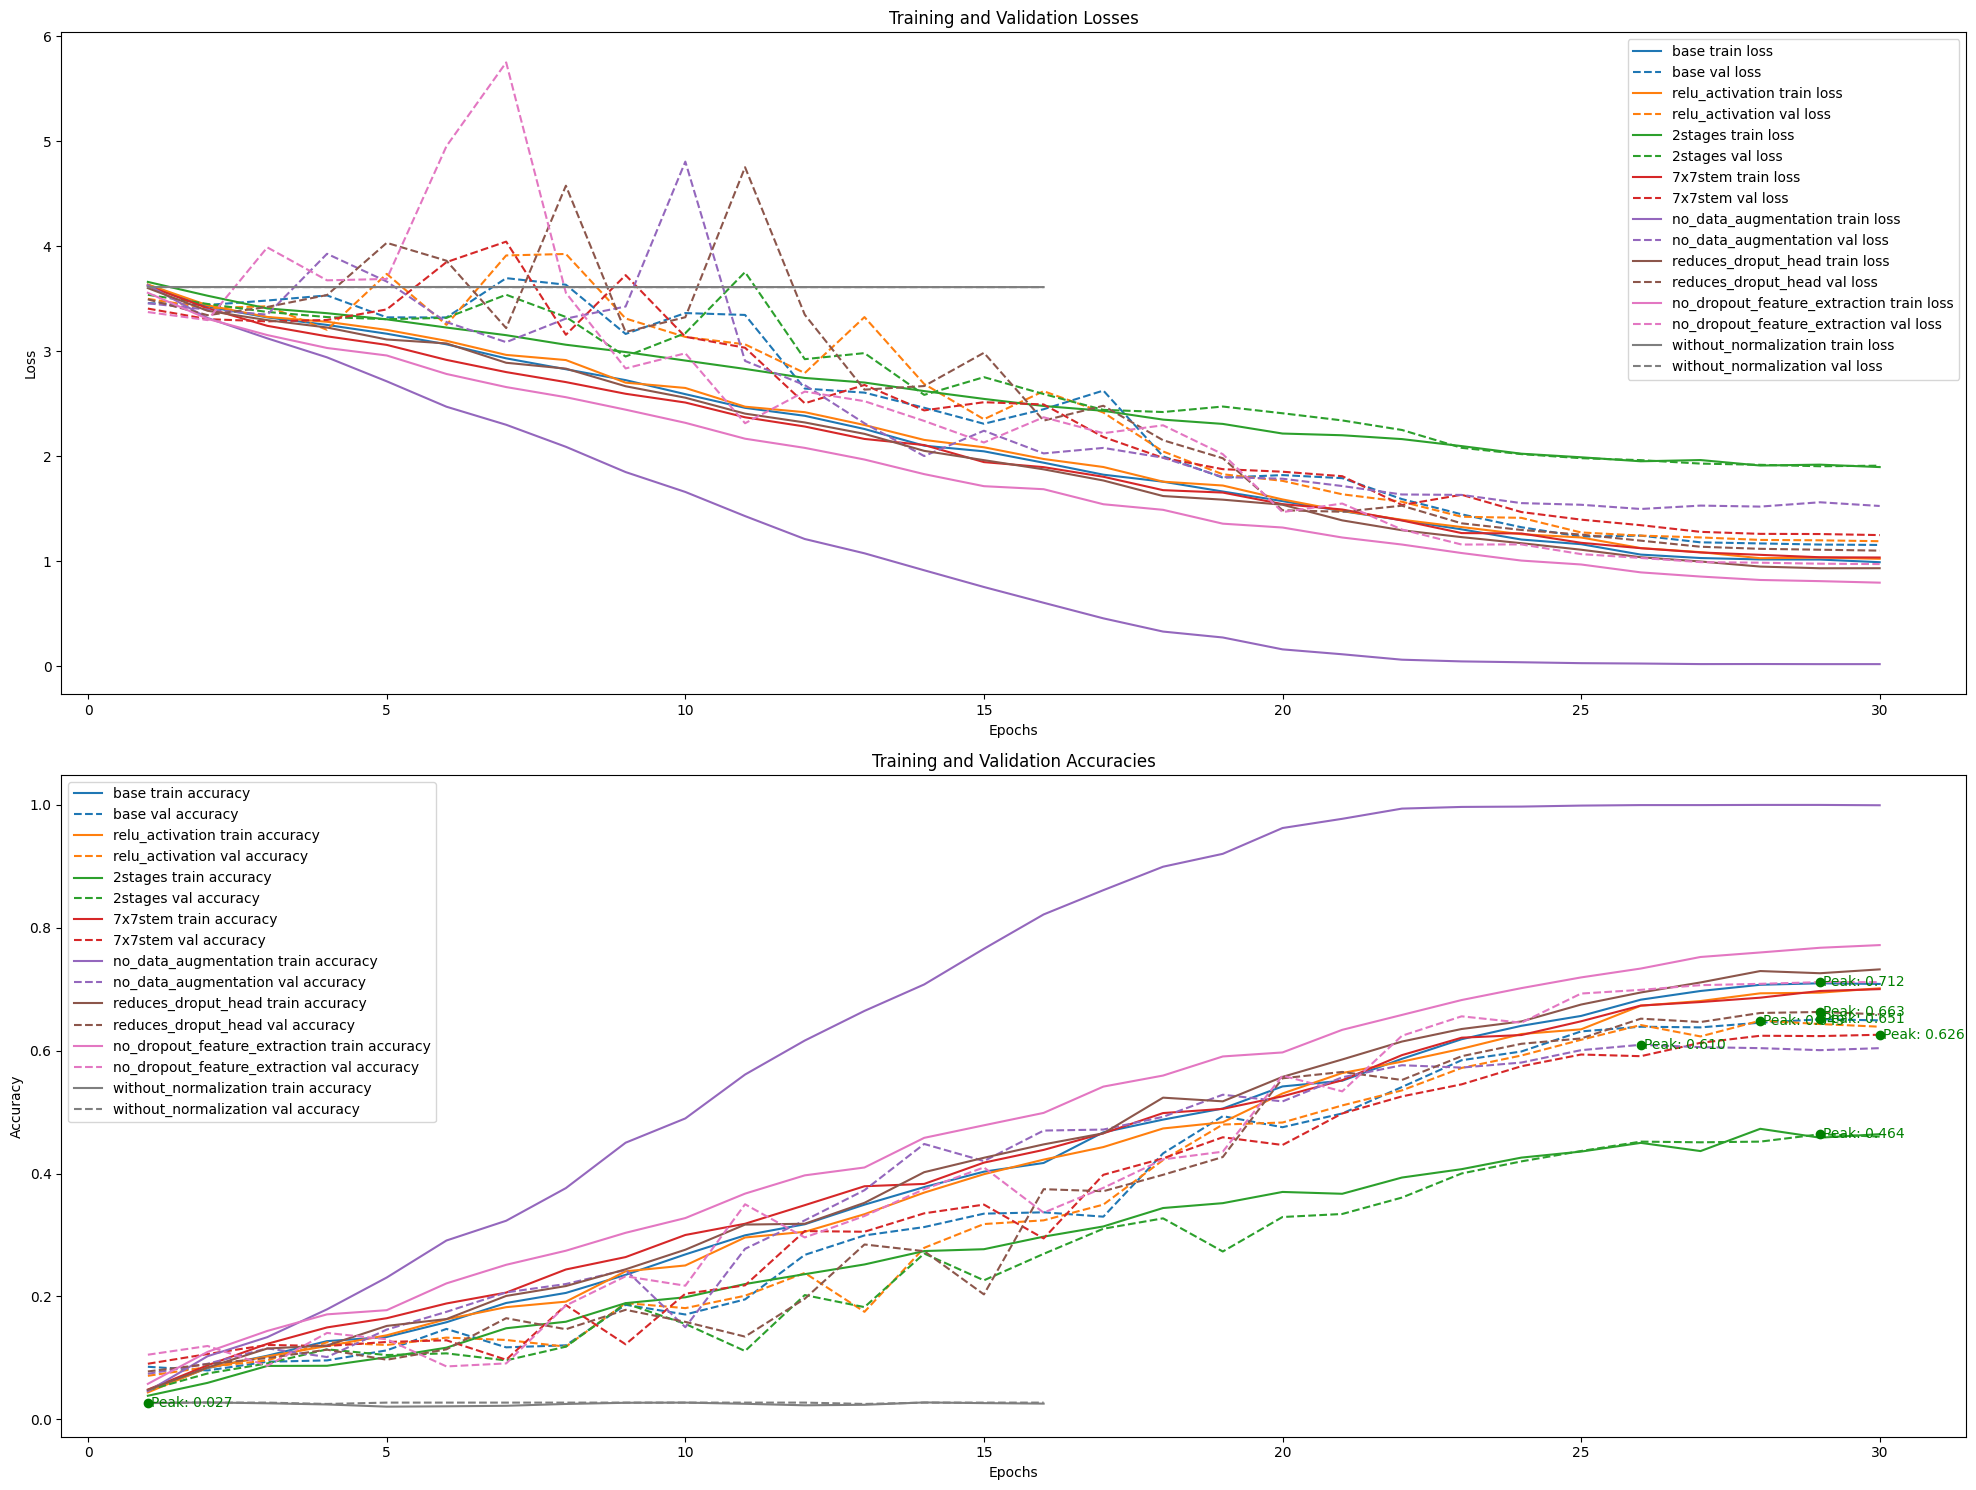

In [ ]:
ablation_study_plotter = ModelVisualizer(all_model_histories, results_df['model_name'], results_df['best_val_acc'])
ablation_study_plotter.plot_histories()

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.

---

# FINE TUNING RESNET-18
The following three experimental setups were used to evaluate fine-tuning strategies with a pretrained ResNet-18 model:

1. **Baseline Fine-Tuning**:

  A pretrained ResNet-18 model was loaded, and its original fully connected (fc) layer was replaced with a single `torch.nn.Linear` layer for classification. The model was then fine-tuned using the configuration without applying any advanced fine-tuning techniques. All parameters were updated during training.

2. **Layer-Wise Fine-Tuning**:

  An identical architecture to the first model was used, but with a more strategic training process:
    * The learning rate was reduced by a factor of 10.
    * Initially, the feature extractor layers were frozen, and only the newly added fc layer (head) was trained for a few epochs.
    * After this initial phase, the entire network was unfrozen, and fine-tuning continued using differential learning rates: a lower learning rate for the feature extractor and a higher one for the head.

3. **Enhanced Head Fine-Tuning**:

  The third model followed the same training procedure as the second setup (freezing, unfreezing, and differential learning rates). However, the head architecture was modified: instead of a single linear layer, a deeper head was used, composed of a torch.nn.Sequential block with two fully connected layers separated by a ReLU activation. This modification aimed to provide more expressive capacity to the classifier.


---


---
The `fine_tune` function implements a two-stage training process with a reduced learning rate (scaled down by 10):

* Stage 1: It freezes the classification head (setting `requires_grad = False`) and trains only the feature extractor for `freeze_epochs` epochs using a uniform learning rate.

* Stage 2: It then unfreezes the head (setting `requires_grad = True`) and fine-tunes the entire model for the remaining epochs, applying different learning rates—higher for the head and lower for the feature extractor—via `lr_groups_fn`.

The function returns the merged training history from both stages and the highest validation accuracy achieved.

---


In [ ]:
def fine_tune(config, model, device, lr_groups_fn, freeze_epochs = 6):
    fn_config = update_config(config, 'lr', config.lr/10)
    epochs = fn_config.n_epochs
    unfreeze_epochs = config.n_epochs - freeze_epochs
    fn_configr = update_config(fn_config, 'n_epochs', freeze_epochs)

    head_params = get_head_params(model)
    for param in head_params:
       param.requires_grad = False

    resnet_history1, acc_value1 = process(fn_configr, model, device, get_param_lr_groups)

    unfreeze_config = update_config(fn_config, 'n_epochs', unfreeze_epochs)

    for param in head_params:
       param.requires_grad = True
    resnet_history2, acc_value2 = process(unfreeze_config, model, device, lr_groups_fn)
    return merge_histories(resnet_history1, resnet_history2), max(acc_value1, acc_value2)


---
The `merge_histories` function is used to combine training records from different phases of fine-tuning. It specifically merges the history from the initial stage—where only the classification head is trained with the feature extractor frozen—with the history from the later phase, where the full model is fine-tuned.

---

In [ ]:
def merge_histories(history1, history2):
    merged_history = {
        'train_losses': history1['train_losses'] + history2['train_losses'],
        'train_accuracies': history1['train_accuracies'] + history2['train_accuracies'],
        'val_losses': history1['val_losses'] + history2['val_losses'],
        'val_accuracies': history1['val_accuracies'] + history2['val_accuracies']
    }
    return merged_history

---
The `get_resnet_model` function loads a pretrained ResNet-18 model and replaces its fully connected (`fc`) layer with a custom head. It then applies Xavier uniform initialization to the weights of all `Linear` layers within the newly assigned head, ensuring better weight distribution for training stability.

---

In [ ]:
def get_resnet_model(head):
    resnet = torchvision.models.resnet18(pretrained=True)
    resnet.fc = head(resnet.fc.in_features)

    if isinstance(resnet.fc, torch.nn.Sequential):
        for layer in resnet.fc:
            if isinstance(layer, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(layer.weight)

    elif isinstance(resnet.fc, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(resnet.fc.weight)

    return resnet

---
The `get_lr_groups` function defines two parameter groups for the optimizer with different learning rates: the feature extractor parameters receive the base learning rate `lr`, while the fully connected (head) layer parameters (`model.fc.parameters(`)) are assigned a learning rate ten times higher (`head_lr = lr * 10`). It returns these groups along with their respective learning rates.

---

In [ ]:
def get_head_params(model):
  return [param for name, param in model.named_parameters() if 'fc' not in str(name)]

def get_lr_groups(model, lr):
  head_lr = lr * 10
  params_1x = get_head_params(model)
  return [{'params': params_1x, 'lr': lr}, {'params': model.fc.parameters(), 'lr': head_lr}], [lr, head_lr]

In [ ]:
resnets_res = []
resnets_histories = []
resnet_configs = {
                  'linear_resnet_without_finetune': (
                                              lambda in_feat: torch.nn.Linear(in_feat,no_of_classes),
                                              process,
                                              get_param_lr_groups),

                'linear_resnet_with_finetune': (
                                            lambda in_feat: torch.nn.Linear(in_feat,no_of_classes),
                                            fine_tune, get_lr_groups),
               'sequential__resnet_with_finetune': (lambda in_feat:  torch.nn.Sequential(
                                        torch.nn.Linear(in_feat, 512),
                                        torch.nn.ReLU(),
                                        torch.nn.Linear(512,no_of_classes)), fine_tune, get_lr_groups)}

for idx, (model_name, configuration) in enumerate(resnet_configs.items()):
    print(f'Evaluating {model_name} model')
    print()
    head_creator, process_finetuner, subgroups_creator = configuration
    model = get_resnet_model(head_creator).to(device)
    history, acc_value = process_finetuner(config, model, device, subgroups_creator)
    resnets_histories.append(history)
    resnets_res.append([model_name, acc_value])

Evaluating linear_resnet_without_finetune model



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]
Epoch 1/30: 100%|██████████| 29/29 [00:12<00:00,  2.27it/s]


Epoch 1/30
Train_Loss: 2.8836 Train_Acc: 0.2723
Val_Loss: 1.0482 Val_Acc: 0.7257


Epoch 2/30: 100%|██████████| 29/29 [00:12<00:00,  2.35it/s]


Epoch 2/30
Train_Loss: 0.9493 Train_Acc: 0.7588
Val_Loss: 0.5923 Val_Acc: 0.8288


...

Epoch 22/24
Train_Loss: 0.1828 Train_Acc: 0.9444
Val_Loss: 0.4339 Val_Acc: 0.8866


Epoch 23/24: 100%|██████████| 29/29 [00:12<00:00,  2.29it/s]


Epoch 23/24
Train_Loss: 0.2032 Train_Acc: 0.9406
Val_Loss: 0.4271 Val_Acc: 0.8893


Epoch 24/24: 100%|██████████| 29/29 [00:12<00:00,  2.27it/s]

Epoch 24/24
Train_Loss: 0.1906 Train_Acc: 0.9455
Val_Loss: 0.4307 Val_Acc: 0.8866


---
# Findings
The findings highlight several key points:

1. The ResNet-18 model trained without applying any fine-tuning methods records the lowest best validation accuracy of `0.8288`, emphasizing the value of employing fine-tuning to enhance model performance.

2. When comparing the two fine-tuned ResNet-18 variants—one with a simple single fully connected layer and the other with a more complex head consisting of two fully connected layers separated by a ReLU activation—the deeper head model achieves a slightly better best validation accuracy of `0.8893` versus `0.8866` for the simpler head.

While the more complex head provides a modest boost in accuracy, the improvement is relatively minor.

---

In [ ]:

resnets_res_df = pd.DataFrame(resnets_res, columns = ['model_name', 'best_val_acc'])
resnets_res

[['linear_resnet_without_finetune', 0.8287895321846008],
 ['linear_resnet_with_finetune', 0.8865866661071777],
 ['sequential__resnet_with_finetune', 0.8893129825592041]]

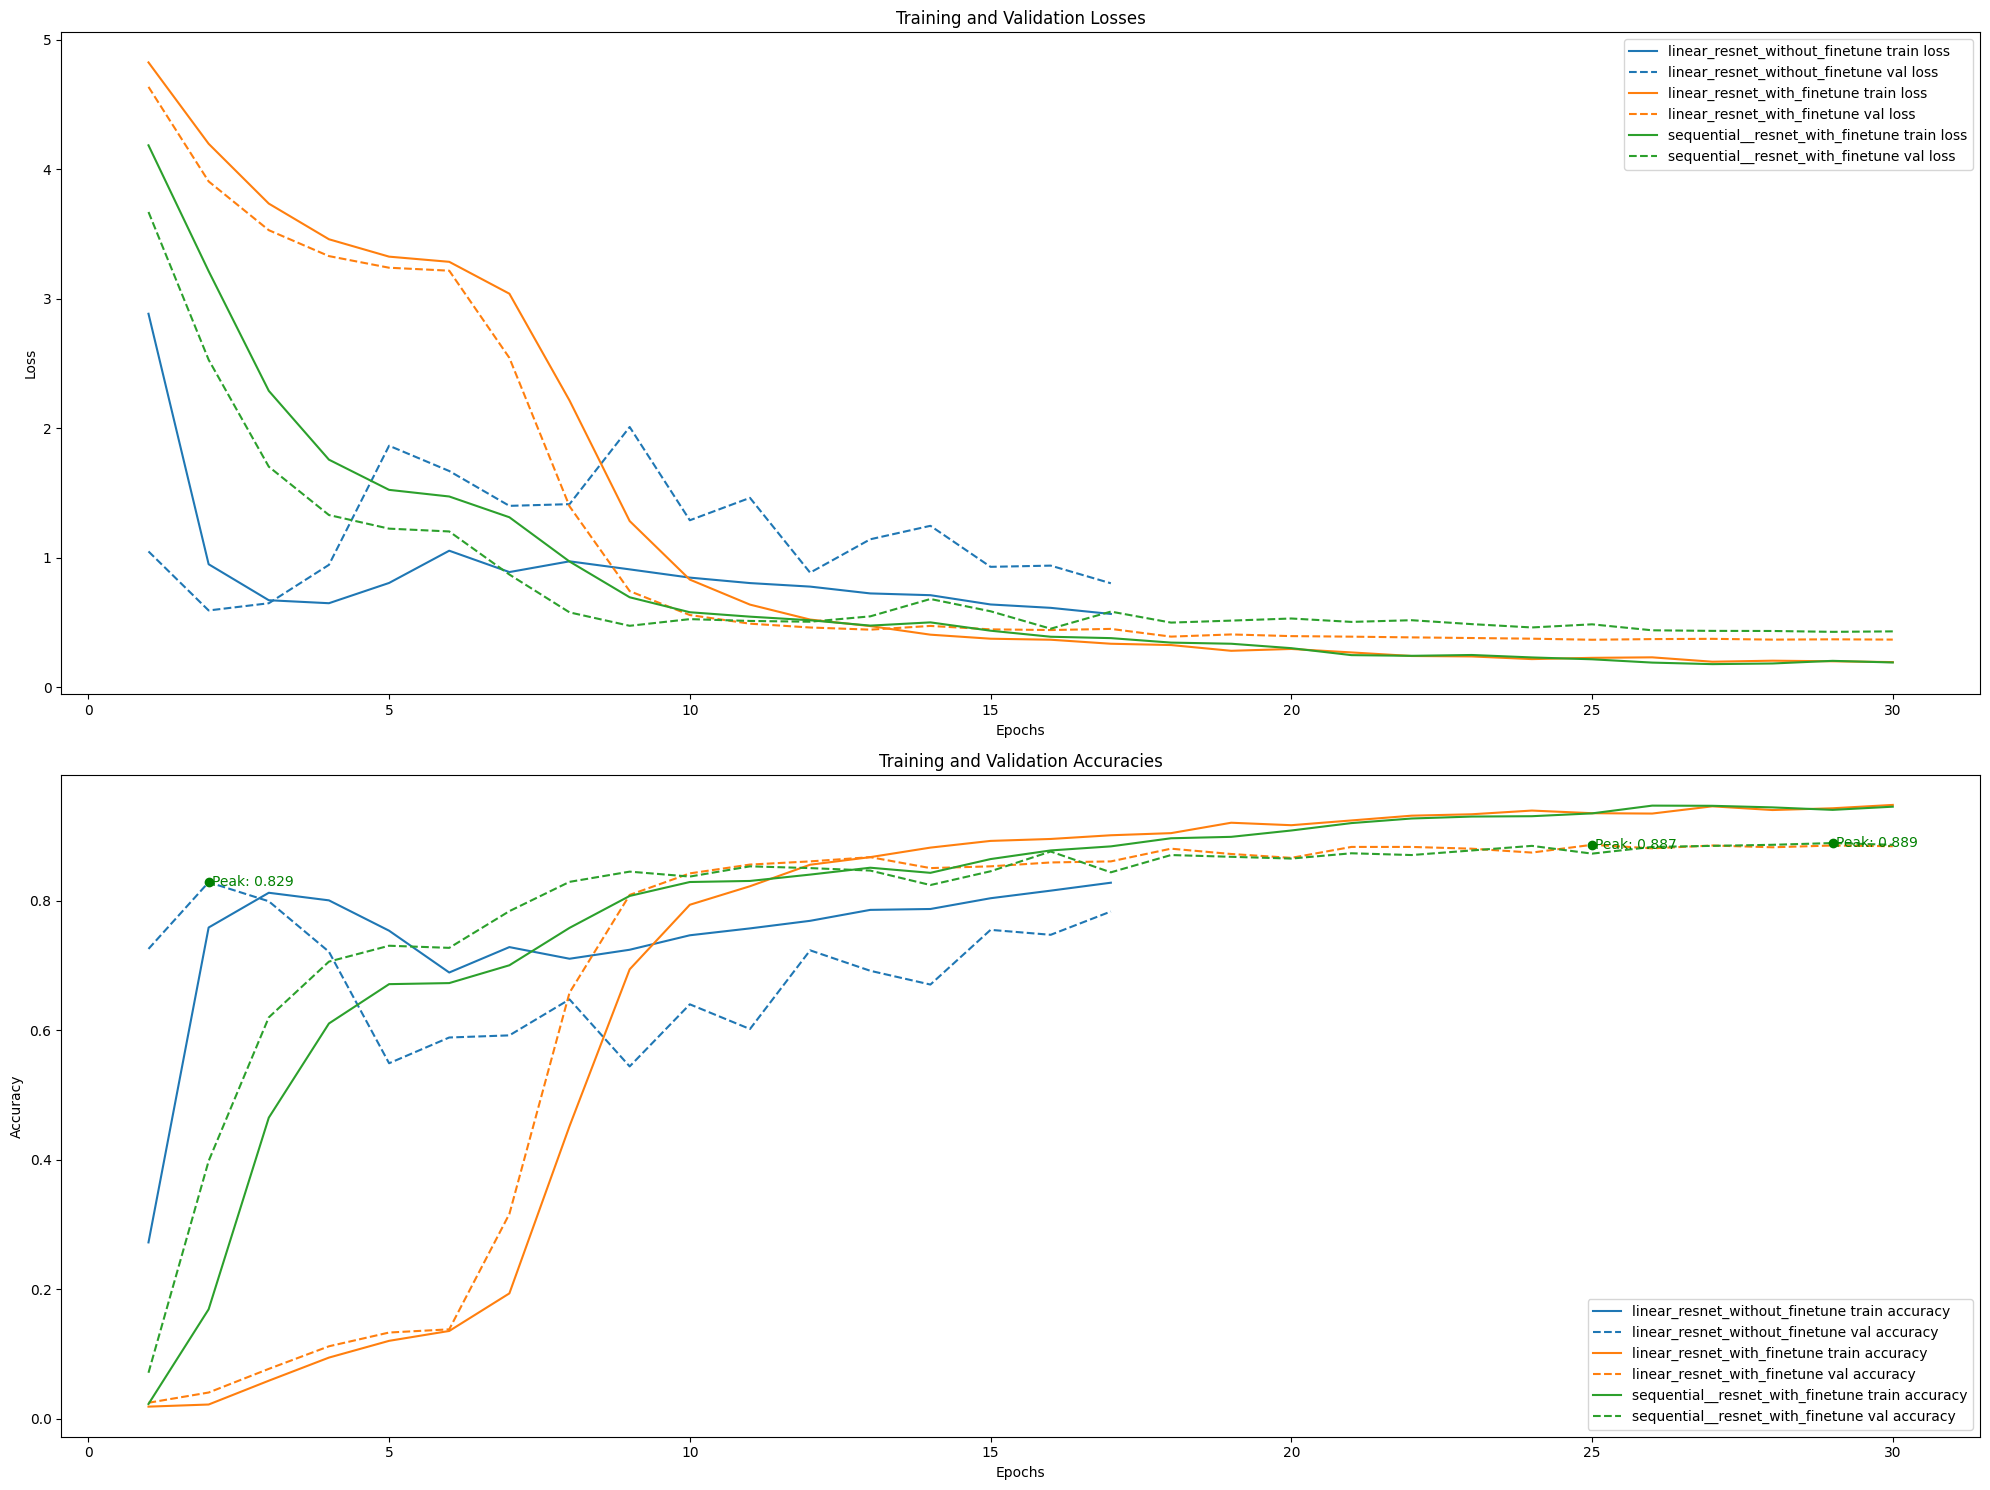

In [ ]:
finetune_plotter = ModelVisualizer(resnets_histories, resnets_res_df['model_name'], resnets_res_df['best_val_acc'])
finetune_plotter.plot_histories()

# **Graph Interpretation**

The first graph shows linear ResNet without fine-tuning exhibits fast training loss reduction but unstable and higher validation loss, indicating overfitting. The linear ResNet with fine-tuning starts with higher losses but shows steady convergence in both training and validation, suggesting better generalization. The sequential ResNet with fine-tuning achieves the lowest and most stable validation loss, demonstrating the best overall performance with minimal overfitting.

The second illustrates training and validation accuracies for three models over 30 epochs. The linear ResNet without fine-tuning peaks early with a validation accuracy of 0.829 but fluctuates heavily, suggesting overfitting and unstable learning. The linear ResNet with fine-tuning shows slow but steady improvement, achieving better long-term performance. The sequential ResNet with fine-tuning outperforms all, reaching the highest validation accuracy of 0.889 with minimal variance, indicating robust and generalizable learning.

# **References**

* Liang, J. (2020, September). Image classification based on RESNET. In Journal of Physics: Conference Series (Vol. 1634, No. 1, p. 012110). IOP Publishing.

* Alom, M. Z., Hasan, M., Yakopcic, C., Taha, T. M., & Asari, V. K. (2021). Inception recurrent convolutional neural network for object recognition. Machine Vision and Applications, 32(1), 28.

* Vrbančič, G., & Podgorelec, V. (2020). Transfer learning with adaptive fine-tuning. IEEE Access, 8, 196197-196211.

* Ranjith, E., Parthiban, L., Latchoumi, T. P., Kumar, S. A., Perera, D. G., & Ramaswamy, S. (2023). An effective content based image retrieval system using deep learning based inception model. Wireless Personal Communications, 133(2), 811-829.